In [1]:
import sys
import os
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from stayrank.config import RAW_LISTINGS_PATH

## Load Data

In [2]:
KEEP_COLUMNS = [
    # Identifiers
    "id", "listing_url", "name", "description",
    # Host information
    "host_id", "host_name", "host_identity_verified",
    # Location information
    "neighbourhood_cleansed", "latitude", "longitude",
    # Property information
    "property_type", "accommodates", "bedrooms", "beds", "amenities",
    # Price information
    "price", "minimum_nights",
    # Review signals
    "number_of_reviews", "review_scores_rating", "review_scores_cleanliness", "review_scores_location"
]

df = pd.read_csv(RAW_LISTINGS_PATH, compression="gzip", low_memory=False)
df = df[[col for col in KEEP_COLUMNS if col in df.columns]].copy()

df["city"] = "Montreal"
df["province"] = "Quebec"

df.shape

(10206, 23)

## Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10206 entries, 0 to 10205
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         10206 non-null  int64  
 1   listing_url                10206 non-null  object 
 2   name                       10206 non-null  object 
 3   description                10031 non-null  object 
 4   host_id                    10206 non-null  int64  
 5   host_name                  10200 non-null  object 
 6   host_identity_verified     10187 non-null  object 
 7   neighbourhood_cleansed     10206 non-null  object 
 8   latitude                   10206 non-null  float64
 9   longitude                  10206 non-null  float64
 10  property_type              10206 non-null  object 
 11  accommodates               10206 non-null  int64  
 12  bedrooms                   9947 non-null   float64
 13  beds                       8698 non-null   flo

In [4]:
df.isna().sum().sort_values(ascending=False)

review_scores_location       2246
review_scores_rating         2245
review_scores_cleanliness    2245
beds                         1508
price                        1239
bedrooms                      259
description                   175
host_identity_verified         19
minimum_nights                  9
host_name                       6
name                            0
host_id                         0
id                              0
listing_url                     0
neighbourhood_cleansed          0
amenities                       0
accommodates                    0
longitude                       0
property_type                   0
latitude                        0
number_of_reviews               0
city                            0
province                        0
dtype: int64

In [5]:
df.head()

,id,listing_url,name,description,host_id,host_name,host_identity_verified,neighbourhood_cleansed,latitude,longitude,...,beds,amenities,price,minimum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,city,province
0,29059,https://www.airbnb.com/rooms/29059,Lovely studio Quartier Latin,CITQ 267153<br />Lovely studio with 1 closed r...,125031,Maryline,t,Ville-Marie,45.51939,-73.56482,...,3.0,"[""Conditioner"", ""Coffee"", ""Wine glasses"", ""Sha...",$190.50,1.0,519,4.69,4.64,4.83,Montreal,Quebec
1,29061,https://www.airbnb.com/rooms/29061,Maison historique - Quartier Latin,Lovely historic house with plenty of period ch...,125031,Maryline,t,Ville-Marie,45.51929,-73.56493,...,2.0,"[""Conditioner"", ""AEG induction stove"", ""Wine g...",$362.04,1.0,175,4.77,4.71,4.87,Montreal,Quebec
2,38118,https://www.airbnb.com/rooms/38118,Beautiful room with a balcony in front of a parc,Nearest metro Papineau. Situated in front of P...,163569,⁨M.⁩,t,Ville-Marie,45.52699,-73.55840,...,4.0,"[""Private entrance"", ""Smoke alarm"", ""Dishes an...",$25.98,31.0,17,4.53,4.24,4.65,Montreal,Quebec
3,50479,https://www.airbnb.com/rooms/50479,L'Arcade Douce,The appartement is sunny and ideally situated ...,231694,Noemie,t,Rosemont-La Petite-Patrie,45.54157,-73.60737,...,4.0,"[""First aid kit"", ""Free dryer \u2013 In unit"",...",$160.00,1.0,371,4.96,4.95,4.85,Montreal,Quebec
4,66247,https://www.airbnb.com/rooms/66247,Modern Loft Next To Basilica Notre Dame In Old...,"Located in the heart of Old Montreal, next to ...",318040,Mohamed,t,Ville-Marie,45.50584,-73.55602,...,1.0,"[""Elevator"", ""Refrigerator"", ""Smoke alarm"", ""E...",$194.38,1.0,612,4.74,4.76,4.90,Montreal,Quebec


## Data Cleaning and Preprocessing

In [6]:
def clean_price(price):
    if isinstance(price, str):
        price = re.sub(r"[^\d.]", "", price)
        try:
            return float(price)
        except ValueError:
            return None
    return price

df["price"] = df["price"].apply(clean_price)

In [7]:
def clean_binary(value):
    if isinstance(value, str):
        value = value.strip().lower()
        if value in ["t", "true", "1", "yes"]:
            return True
        elif value in ["f", "false", "0", "no"]:
            return False
    return None

df["host_identity_verified"] = df["host_identity_verified"].apply(clean_binary)

In [8]:
def clean_property_type(property_type):
    """
    Cleans the property_type column and extracts building_type and room_type.
    """
    if not isinstance(property_type, str):
        return pd.Series({"building_type": None, "room_type": None})
    
    property_type = property_type.strip().lower()

    if re.search(r"^entire", property_type):
        m = re.search(r"^entire\s+(.*)", property_type)
        building_type = m.group(1).capitalize() if m else None
        room_type = "Entire Property"
    
    elif re.search(r"^(private|room)", property_type):
        m = re.search(r"^(private )?room in\s+(.*)", property_type)
        building_type = m.group(2).capitalize() if m else None
        room_type = "Private Room"
    
    elif re.search(r"^shared", property_type):
        m = re.search(r"^shared room in\s+(.*)", property_type)
        building_type = m.group(1).capitalize() if m else None
        room_type = "Shared Room"
    
    else:
        building_type = property_type.capitalize()
        room_type = None
    
    return pd.Series({"building_type": building_type, "room_type": room_type})

df[["property_type", "room_type"]] = df["property_type"].apply(clean_property_type)

In [9]:
def parse_amenities(amenities):
    if isinstance(amenities, str):
        return re.findall(r'"(.*?)"', amenities)
    return []

df["amenities"] = df["amenities"].apply(parse_amenities)

In [10]:
cleaned_fields = ["price", "host_identity_verified", "property_type", "room_type", "amenities"]

df[cleaned_fields].head(10)

,price,host_identity_verified,property_type,room_type,amenities
0,190.50,True,Rental unit,Entire Property,"[Conditioner, Coffee, Wine glasses, Shared bac..."
1,362.04,True,Home,Entire Property,"[Conditioner, AEG induction stove, Wine glasse..."
2,25.98,True,Rental unit,Private Room,"[Private entrance, Smoke alarm, Dishes and sil..."
3,160.00,True,Rental unit,Entire Property,"[First aid kit, Free dryer \u2013 In unit, Smo..."
4,194.38,True,Loft,Entire Property,"[Elevator, Refrigerator, Smoke alarm, Extra pi..."
5,54.63,True,Rental unit,Entire Property,"[Coffee, Paid parking garage on premises \u201..."
6,549.41,True,Home,Entire Property,"[Children\u2019s dinnerware, Conditioner, Coff..."
7,258.71,True,Rental unit,Entire Property,"[Hangers, Wifi, Dedicated workspace, Heating, ..."
8,92.14,True,Rental unit,Entire Property,"[Refrigerator, Smoke alarm, Coffee maker, Air ..."
9,388.00,True,Rental unit,Entire Property,"[Refrigerator, Smoke alarm, Outdoor furniture,..."


## Check duplicates

In [11]:
{
    "duplicated_ids": df["id"].duplicated().sum() / len(df),
    "duplicated_listing_urls": df["listing_url"].duplicated().sum() / len(df),
    "duplicated_hosts": df["host_id"].duplicated().sum() / len(df),
}

{'duplicated_ids': np.float64(0.0),
 'duplicated_listing_urls': np.float64(0.0),
 'duplicated_hosts': np.float64(0.6229668822261415)}

In [12]:
# Host Listing Distribution
df.groupby("host_id").size().describe()

count    3848.000000
mean        2.652287
std         6.246575
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       141.000000
dtype: float64

## Property type exploration

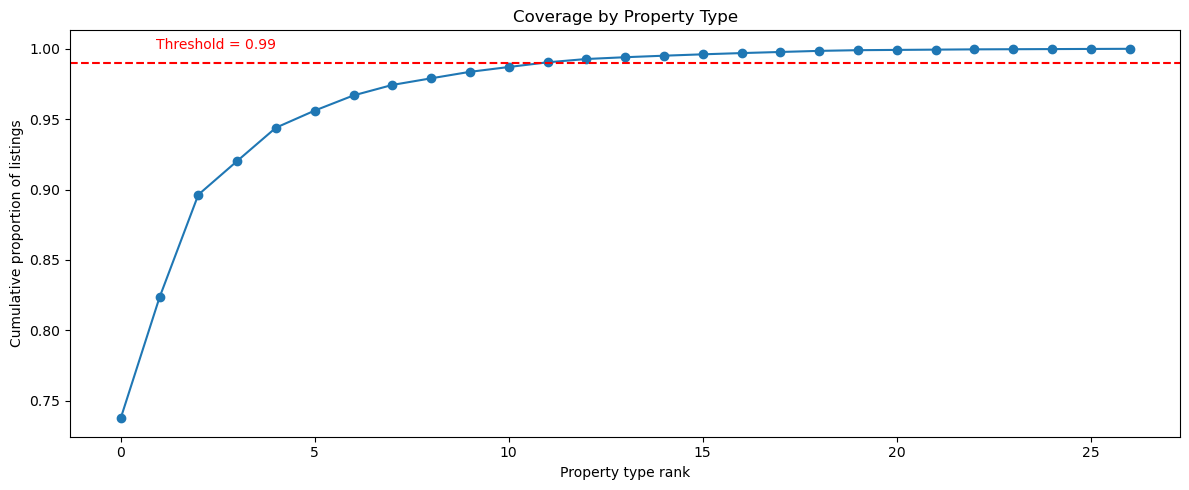

In [13]:
building_type_counts = df["property_type"].value_counts(ascending=False)

coverage = (
    building_type_counts
    .sort_values(ascending=False)
    .cumsum()
    .div(building_type_counts.sum())
)

plt.figure(figsize=(12, 5))
plt.plot(coverage.values, marker='o')
plt.axhline(0.99, color="red", linestyle="--")
plt.text(max(coverage.values) * 0.9, 1.0, f'Threshold = {0.99}', color='r')
plt.xlabel("Property type rank")
plt.ylabel("Cumulative proportion of listings")
plt.title("Coverage by Property Type")
plt.tight_layout()
plt.show()

In [14]:
# Group rare property types into "Other" category (if not in the top 10 most common property types)
threshold = building_type_counts.nlargest(10).min()  # Minimum count of the top 10 property types
df["property_category"] = df["property_type"].where(
    df["property_type"].map(building_type_counts) >= threshold,
    "Other"
)

In [15]:
print("Property categories distribution:\n-----------")
print(df["property_category"].value_counts(dropna=False, ascending=False).head(30))

print("\n")

print("Room types distribution:\n-----------")
print(df["room_type"].value_counts(dropna=False, ascending=False))

Property categories distribution:
-----------
property_category
Rental unit           7527
Condo                  876
Home                   745
Loft                   244
Hotel                  242
Other                  167
Townhouse              124
Aparthotel             110
Serviced apartment      76
Hostel                  48
Bed and breakfast       47
Name: count, dtype: int64


Room types distribution:
-----------
room_type
Entire Property    8260
Private Room       1897
Shared Room          30
None                 19
Name: count, dtype: int64


In [16]:
TYPES_RENAMES = {
    "Rental unit": "Apartment",
    "Home": "House"
}

df["property_category"] = df["property_type"].replace(TYPES_RENAMES)

## Amenities exploration

In [17]:
amenity_counts = Counter(amenity for amenities in df["amenities"] for amenity in amenities)

n_listings = len(df)

amenity_coverage = (
    pd.DataFrame(amenity_counts.items(), columns=["amenity", "count"])
    .assign(coverage=lambda x: round(100 * x["count"] / n_listings, 2))
    .sort_values(by="coverage", ascending=False)
)

print(f"Total number of unique amenities: {len(amenity_coverage)}")
print(f"Number of amenities with coverage >= 20%: {amenity_coverage.query('coverage >= 20').shape[0]}")

top_amenities = amenity_coverage.query('coverage >= 20').amenity.tolist()

print(f"Top {len(top_amenities)} amenities:")
display(amenity_coverage.head(len(top_amenities)).reset_index(drop=True))

Total number of unique amenities: 2458
Number of amenities with coverage >= 20%: 52
Top 52 amenities:


,amenity,count,coverage
0,Kitchen,9726,95.30
1,Wifi,9629,94.35
2,Smoke alarm,9501,93.09
3,Hot water,8518,83.46
4,Dishes and silverware,8023,78.61
5,Cooking basics,7832,76.74
6,Hangers,7761,76.04
7,Bed linens,7702,75.47
8,Refrigerator,7678,75.23
9,Microwave,7627,74.73
